8. Heart Disease Prediction (Classification)
Dataset
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
Problem Statement
Build a model to predict whether a patient has heart disease based on
clinical measurements.
Target
target (0 = No disease, 1 = Disease)
Key Features
● Age
● Sex
● Cholesterol
● Resting blood pressure
● Max heart rate
● Chest pain type
Project Hint
EDA
● Correlation heatmap
● Distribution plots
Data Processing
● Standardize numeric variables
● Handle class imbalance
Models
● Logistic Regression
● Random Forest
● XGBoost
Evaluation
● ROC-AUC
● Precision-Recall
Advanced
● SHAP for feature importance

In [5]:
# ── STEP 1: IMPORT LIBRARIES ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

import shap
import warnings
warnings.filterwarnings("ignore")

print(" Libraries imported successfully!\n")

 Libraries imported successfully!



In [14]:
# ── STEP 2: LOAD DATASET ─────
# Download from Kaggle and place heart.csv in the same folder
# Fallback: load locally
df = pd.read_csv("/content/heart.csv")
print("Dataset loaded locally")

print(f"   Shape: {df.shape}")
print(df.head())

Dataset loaded locally
   Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  



──── Basic Info ────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

──── Missing Values ────
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca       

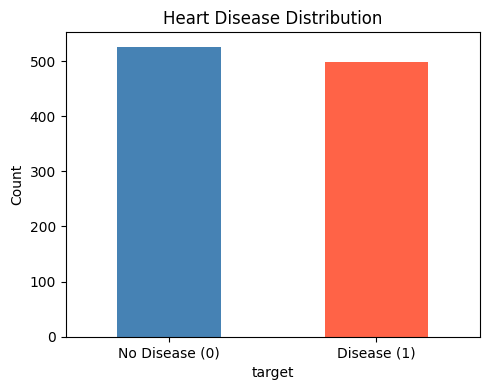

 Plot saved: plot_01_target_distribution.png


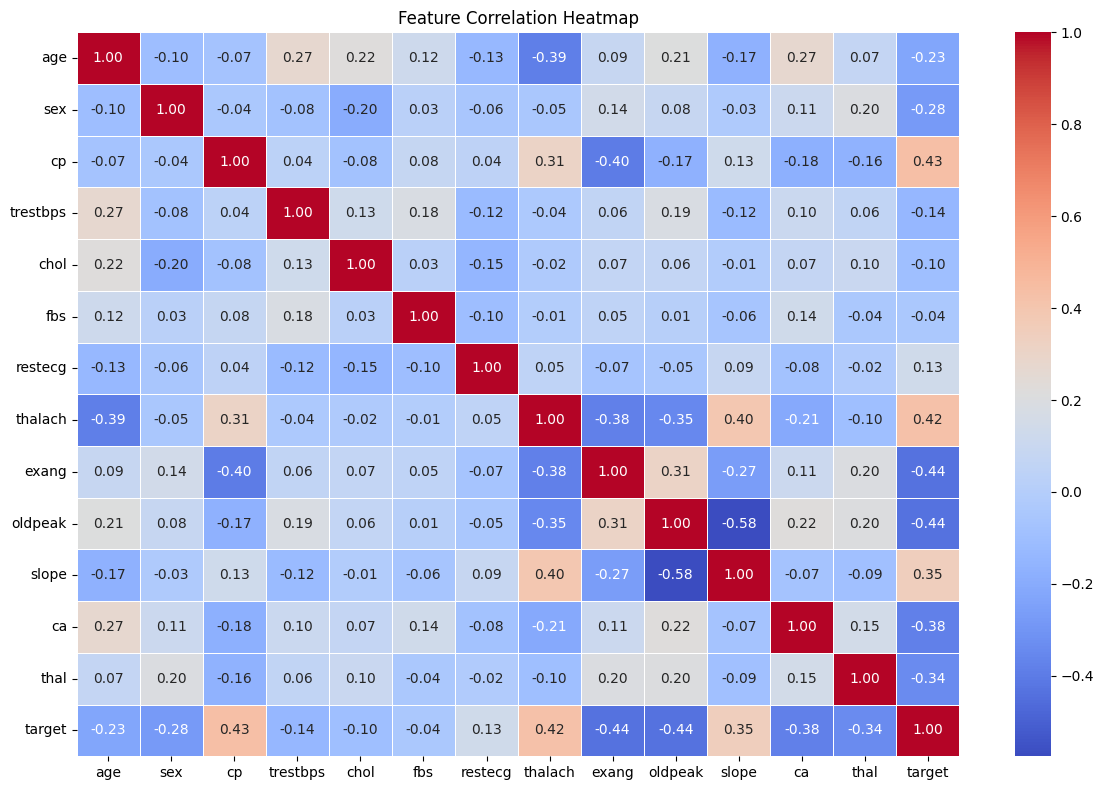

 Plot saved: plot_02_correlation_heatmap.png


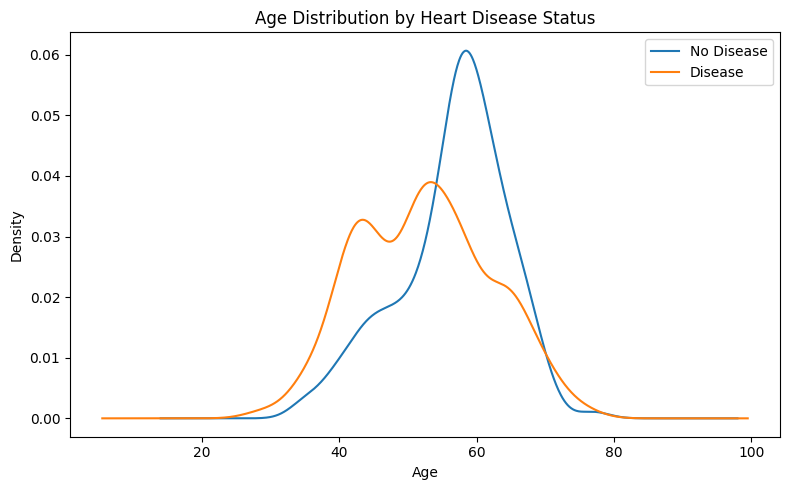

 Plot saved: plot_03_age_distribution.png


In [7]:
# ── STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ───
print("\n──── Basic Info ────")
print(df.info())

print("\n──── Missing Values ────")
print(df.isnull().sum())

print("\n──── Class Distribution ────")
print(df["target"].value_counts())
# 0 = No disease, 1 = Disease

# -- Plot 1: Target distribution
plt.figure(figsize=(5, 4))
df["target"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Heart Disease Distribution")
plt.xticks([0, 1], ["No Disease (0)", "Disease (1)"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot_01_target_distribution.png", dpi=120)
plt.show()
print(" Plot saved: plot_01_target_distribution.png")

# -- Plot 2: Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("plot_02_correlation_heatmap.png", dpi=120)
plt.show()
print(" Plot saved: plot_02_correlation_heatmap.png")

# -- Plot 3: Age distribution by target
plt.figure(figsize=(8, 5))
df.groupby("target")["age"].plot(kind="kde")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.legend(["No Disease", "Disease"])
plt.tight_layout()
plt.savefig("plot_03_age_distribution.png", dpi=120)
plt.show()
print(" Plot saved: plot_03_age_distribution.png")

In [8]:
# ── STEP 4: FEATURE ENGINEERING ───
# The dataset columns:
#   age, sex, cp (chest pain), trestbps, chol, fbs, restecg,
#   thalach (max heart rate), exang, oldpeak, slope, ca, thal, target

# Create a meaningful derived feature
df["age_thalach_ratio"] = df["age"] / (df["thalach"] + 1)
# Higher ratio = older + lower max HR → possibly higher risk

print("\n Feature engineering done. New feature: age_thalach_ratio")
print(df[["age", "thalach", "age_thalach_ratio"]].head())


 Feature engineering done. New feature: age_thalach_ratio
   age  thalach  age_thalach_ratio
0   52      168           0.307692
1   53      155           0.339744
2   70      125           0.555556
3   61      161           0.376543
4   62      106           0.579439


In [9]:
# ── STEP 5: PREPROCESSING ───
X = df.drop("target", axis=1)
y = df["target"]

# Train / test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise numeric features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n Data split — Train: {X_train.shape}, Test: {X_test.shape}")



 Data split — Train: (820, 14), Test: (205, 14)


In [10]:
# ── STEP 6: TRAIN MODELS ───

# Helper to evaluate any model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    print(f"\n{'='*50}")
    print(f"  MODEL: {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred,
                                target_names=["No Disease", "Disease"]))
    roc = roc_auc_score(y_te, y_proba)
    print(f"  ROC-AUC Score : {roc:.4f}")

    # Cross-validation
    cv = cross_val_score(model, X_tr, y_tr, cv=5, scoring="roc_auc")
    print(f"  CV ROC-AUC    : {cv.mean():.4f} ± {cv.std():.4f}")

    return model, y_pred, y_proba, roc


# ── Model A: Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42)
lr, lr_pred, lr_proba, lr_roc = evaluate_model(
    "Logistic Regression", lr,
    X_train_scaled, X_test_scaled, y_train, y_test
)

# ── Model B: Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf, rf_pred, rf_proba, rf_roc = evaluate_model(
    "Random Forest", rf,
    X_train, X_test, y_train, y_test       # tree models don't need scaling
)

# ── Model C: XGBoost ──
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False,
                     eval_metric="logloss", random_state=42)
xgb, xgb_pred, xgb_proba, xgb_roc = evaluate_model(
    "XGBoost", xgb,
    X_train, X_test, y_train, y_test
)


  MODEL: Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.90      0.70      0.79       100
     Disease       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205

  ROC-AUC Score : 0.9298
  CV ROC-AUC    : 0.9112 ± 0.0221

  MODEL: Random Forest
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

  ROC-AUC Score : 1.0000
  CV ROC-AUC    : 0.9986 ± 0.0023

  MODEL: XGBoost
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00    

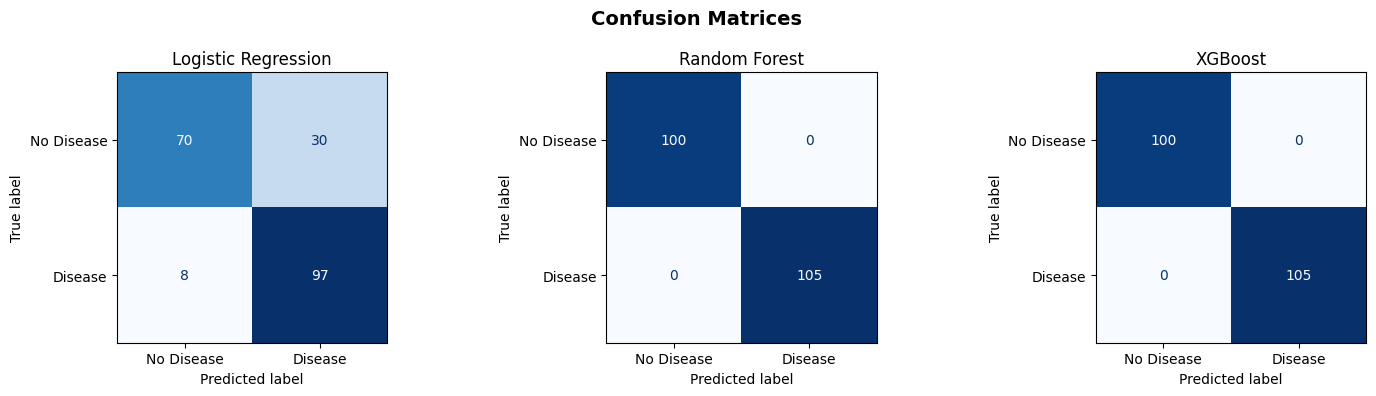

Plot saved: plot_04_confusion_matrices.png


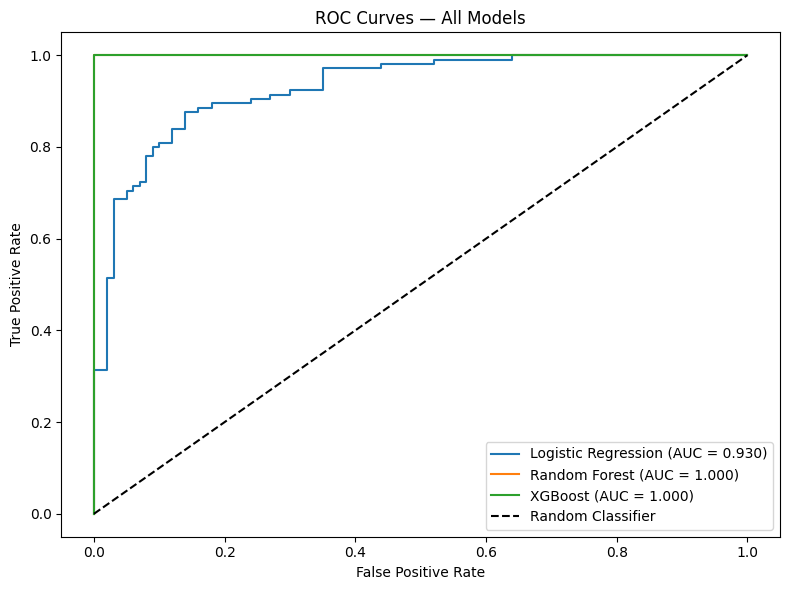

Plot saved: plot_05_roc_curves.png


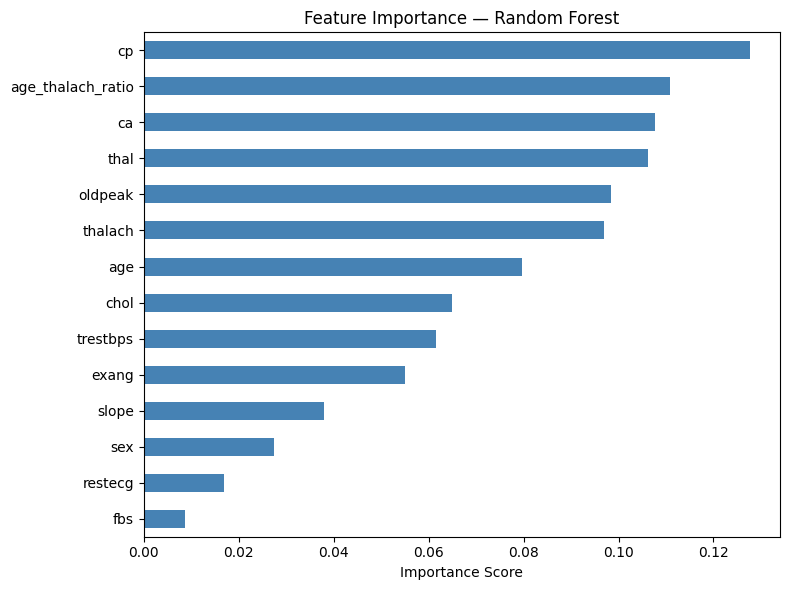

Plot saved: plot_06_feature_importance.png


In [11]:
# ── STEP 7: VISUALISE RESULTS ────

# -- Plot 4: Confusion matrices (side by side)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("XGBoost",             xgb_pred),
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_04_confusion_matrices.png", dpi=120)
plt.show()
print("Plot saved: plot_04_confusion_matrices.png")

# -- Plot 5: ROC Curves
plt.figure(figsize=(8, 6))
for name, proba, roc in [
    ("Logistic Regression", lr_proba,  lr_roc),
    ("Random Forest",       rf_proba,  rf_roc),
    ("XGBoost",             xgb_proba, xgb_roc),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.savefig("plot_05_roc_curves.png", dpi=120)
plt.show()
print("Plot saved: plot_05_roc_curves.png")

# -- Plot 6: Feature importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_06_feature_importance.png", dpi=120)
plt.show()
print("Plot saved: plot_06_feature_importance.png")


 Computing SHAP values for XGBoost...


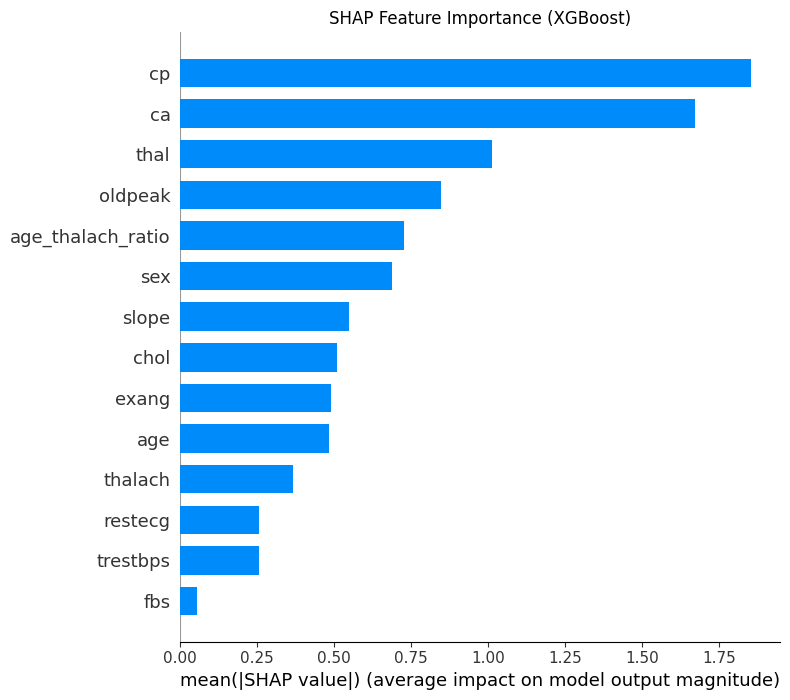

Plot saved: plot_07_shap_summary.png


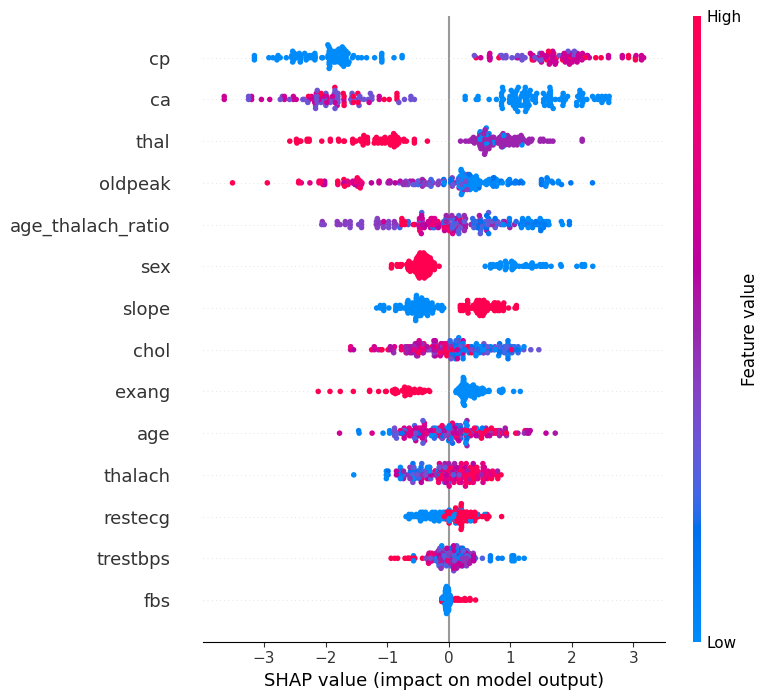

Plot saved: plot_08_shap_beeswarm.png


In [12]:
# ── STEP 8: SHAP EXPLAINABILITY (Advanced) ────
print("\n Computing SHAP values for XGBoost...")

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot — global feature impact
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig("plot_07_shap_summary.png", dpi=120)
plt.show()
print("Plot saved: plot_07_shap_summary.png")

# Beeswarm plot — direction + magnitude
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("plot_08_shap_beeswarm.png", dpi=120)
plt.show()
print("Plot saved: plot_08_shap_beeswarm.png")

In [13]:
# ── STEP 9: MODEL COMPARISON SUMMARY ───
summary = pd.DataFrame({
    "Model":   ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [round(lr_roc, 4), round(rf_roc, 4), round(xgb_roc, 4)],
})
print("\n──── Final Model Comparison ────")
print(summary.to_string(index=False))

best = summary.loc[summary["ROC-AUC"].idxmax(), "Model"]
print(f"\n Best model: {best}")
print("\n All done! Check the generated PNG files for visualisations.")


──── Final Model Comparison ────
              Model  ROC-AUC
Logistic Regression   0.9298
      Random Forest   1.0000
            XGBoost   1.0000

 Best model: Random Forest

 All done! Check the generated PNG files for visualisations.
